
 Imports & Chargement 

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Chemins
WOO_PATH  = "./final_tables/woo_final.csv"
TECH_PATH = "./final_tables/technicians_final.csv"

# Chargement
woo  = pd.read_csv(WOO_PATH,  encoding="utf-8-sig")
tech = pd.read_csv(TECH_PATH, encoding="utf-8-sig")

print(f"WOO chargé        : {woo.shape[0]} opérations, {woo.shape[1]} colonnes")
print(f"Techniciens chargé : {tech.shape[0]} techniciens, {tech.shape[1]} colonnes")

print(f"\nColonnes WOO :")
for col in woo.columns:
    print(f"   • {col}")

print(f"\nColonnes TECHNICIANS :")
for col in tech.columns:
    print(f"   • {col}")

WOO chargé        : 1096 opérations, 30 colonnes
Techniciens chargé : 7 techniciens, 19 colonnes

Colonnes WOO :
   • pk_woo_id
   • status
   • operation_key
   • operation_description
   • operation_type
   • operation_subtype
   • operation_order
   • priority_score
   • duration
   • duration_unit
   • confirmed_work
   • confirmed_work_unit
   • required_skill_desc
   • predecessor_operation_key
   • order_basic_start_date
   • order_basic_end_date
   • operation_scheduled_start
   • operation_scheduled_end
   • fk_assigned_technician_id
   • asset_status
   • asset_description
   • asset_criticality
   • asset_address_street
   • asset_address_door
   • asset_address_post_code
   • asset_address_city
   • asset_address_region
   • customer_description
   • is_corrective
   • duration_minutes

Colonnes TECHNICIANS :
   • pk_technician_id
   • technician_status
   • technician_first_name
   • technician_last_name
   • technician_full_name
   • skill_description
   • availability_st

- Préparation du scoring et des deadlines

 On prépare 3 éléments :
 1. criticality_score  → Bad=1, Adequate=2, Good=3
 2. deadline           → Corrective=ASAP, Preventive=order_basic_end_date
 3. Tri final          → [priority_score, criticality_score, deadline]

 ── Date de début de simulation 
 C'est le jour J à partir duquel le planner commence à planifier
 Les Correctives sans date seront planifiées dès ce jour

In [2]:


DATE_DEBUT = datetime(2024, 11, 4)  
print(f"Date début simulation : {DATE_DEBUT.strftime('%d/%m/%Y')}")

# ── 1. criticality_score 
# asset_criticality est du texte (Bad/Adequate/Good)
# L'algorithme a besoin d'un nombre pour trier
# Bad=1 car c'est la priorité la plus haute (asset en mauvais état)

criticality_map = {
    "Bad"      : 1,
    "Adequate" : 2,
    "Good"     : 3,
}
woo["criticality_score"] = woo["asset_criticality"].map(criticality_map).fillna(2).astype(int)
# fillna(2) → si asset inconnu (113 ops sans asset) → Adequate par défaut

print("\n── criticality_score ")
print(woo.groupby(["asset_criticality", "criticality_score"]).size().reset_index(name="nb").to_string())
print(f"\nSans asset (fillna=2) : {woo['asset_criticality'].isna().sum()} opérations")

# ── 2. deadline 
# RÈGLE :
# Corrective (is_corrective=1) → pas de date → deadline = DATE_DEBUT (ASAP)
# Preventive (is_corrective=0) → a une date  → deadline = order_basic_end_date

def compute_deadline(row):
    if row["is_corrective"] == 1:
        # Corrective → planifier ASAP
        # Deadline = horizon complet (30 jours)
        # L'urgence est gérée par priority_score, pas par deadline
        return DATE_DEBUT + timedelta(days=30)
    else:
        # Preventive → respecter la date d'échéance
        if pd.notna(row["order_basic_end_date"]):
            return datetime.strptime(str(row["order_basic_end_date"]), "%d/%m/%Y")
        else:
            return DATE_DEBUT + timedelta(days=30)

woo["deadline"] = woo.apply(compute_deadline, axis=1)

print("\n── deadline ")
print(f"Correctives avec deadline = DATE_DEBUT : {(woo['is_corrective']==1).sum()}")
print(f"Preventives avec date réelle           : {(woo['is_corrective']==0).sum()}")
print(f"\nExemple deadlines Corrective :")
print(woo[woo["is_corrective"]==1][["pk_woo_id","operation_subtype","deadline"]].head(3).to_string())
print(f"\nExemple deadlines Preventive :")
print(woo[woo["is_corrective"]==0][["pk_woo_id","operation_subtype","order_basic_end_date","deadline"]].head(3).to_string())

# ── 3. Tri final des opérations 
# Ordre de tri :
#   1er critère : priority_score ASC 'Ascending'   (1=Breakdown en premier)
#   2ème critère: criticality_score ASC (1=Bad en premier à égalité)
#   3ème critère: deadline ASC          (date la plus proche en premier)

woo_sorted = woo.sort_values(
    by=["priority_score", "criticality_score", "deadline"],
    ascending=[True, True, True]
).reset_index(drop=True)

print("\n── Tri final des opérations ─────────────────────────────────")
print(f"Total opérations triées : {len(woo_sorted)}")
print(f"\nTop 10 premières opérations à planifier :")
print(woo_sorted[[
    "pk_woo_id", "operation_subtype", "priority_score",
    "asset_criticality", "criticality_score", "deadline"
]].head(10).to_string())

print(f"\n10 dernières opérations à planifier :")
print(woo_sorted[[
    "pk_woo_id", "operation_subtype", "priority_score",
    "asset_criticality", "criticality_score", "deadline"
]].tail(10).to_string())

print(f"\n Opérations prêtes à être planifiées dans cet ordre")

Date début simulation : 04/11/2024

── criticality_score 
  asset_criticality  criticality_score   nb
0          Adequate                  2  347
1               Bad                  1  284
2              Good                  3  352

Sans asset (fillna=2) : 113 opérations

── deadline 
Correctives avec deadline = DATE_DEBUT : 876
Preventives avec date réelle           : 220

Exemple deadlines Corrective :
   pk_woo_id operation_subtype   deadline
5        137         Breakdown 2024-12-04
6        138         Breakdown 2024-12-04
7        139         Breakdown 2024-12-04

Exemple deadlines Preventive :
   pk_woo_id operation_subtype order_basic_end_date   deadline
0        132           monthly            8/11/2024 2024-11-08
1        133           monthly            8/11/2024 2024-11-08
2        134           monthly            8/11/2024 2024-11-08

── Tri final des opérations ─────────────────────────────────
Total opérations triées : 1096

Top 10 premières opérations à planifier :
 

 Construction du calendrier des techniciens
 POURQUOI un calendrier ?
 L'algorithme doit savoir à chaque instant :
   - Quels créneaux sont déjà occupés pour chaque technicien
   - Quel est le prochain créneau libre disponible

 STRUCTURE :
 Un dictionnaire Python où chaque technicien a une liste de créneaux déjà occupés (start, end)

 Exemple après quelques assignations :
 {
   6  : [(2024-11-04 07:00, 2024-11-04 07:30),   ← Luc occupé 07:00-07:30
          (2024-11-04 07:30, 2024-11-04 08:00)],  ← Luc occupé 07:30-08:00
   11 : [],                                        ← André libre
   ...
 }

In [3]:
from datetime import datetime, timedelta

# ── Paramètres du shift ───────────────────────────────────────────
SHIFT_START   = "07:00"
SHIFT_END     = "17:00"
PAUSE_START   = "11:00"
PAUSE_END     = "12:00"
DATE_DEBUT    = datetime(2024, 11, 4)
NB_JOURS_MAX  = 30    # horizon de planification : 30 jours

# ── Fonctions utilitaires pour les créneaux ───────────────────────

def str_to_time(date, heure_str):
    """
    Combine une date et une heure string en datetime
    Exemple : date=2024-11-04, heure="07:30" → datetime(2024,11,4,7,30)
    """
    h, m = map(int, heure_str.split(":"))
    return date.replace(hour=h, minute=m, second=0, microsecond=0)

def get_shift_slots(date):
    """
    Retourne les 2 créneaux disponibles pour une journée donnée :
    Matin      : 07:00 → 11:00 (240 min)
    Après-midi : 12:00 → 17:00 (300 min)
    La pause 11:00-12:00 est automatiquement exclue
    """
    matin_start = str_to_time(date, SHIFT_START)   # 07:00
    matin_end   = str_to_time(date, PAUSE_START)   # 11:00
    apm_start   = str_to_time(date, PAUSE_END)     # 12:00
    apm_end     = str_to_time(date, SHIFT_END)     # 17:00
    return [(matin_start, matin_end), (apm_start, apm_end)]

def find_free_slot(calendrier_tech, date, duration_minutes):
    """
    Cherche le premier créneau libre de 'duration_minutes' minutes
    pour un technicien sur une journée donnée.

    Logique :
    1. On vérifie que ce n'est pas un weekend
    2. On parcourt les créneaux du shift (matin + après-midi)
    3. Dans chaque créneau, on cherche un espace libre
    4. On vérifie qu'aucune opération déjà planifiée ne chevauche

    Retourne : (start, end) si créneau trouvé, None sinon
    """
    # ── FILTRE WEEKEND ────────────────────────────────────────────
    # weekday() retourne :
    # 0=Lundi, 1=Mardi, 2=Mercredi, 3=Jeudi, 4=Vendredi
    # 5=Samedi, 6=Dimanche
    # Si >= 5 → weekend → pas de travail → retourner None
    if date.weekday() >= 5:
        return None

    slots = get_shift_slots(date)
    duree = timedelta(minutes=duration_minutes)

    for slot_start, slot_end in slots:
        # On commence au début du créneau
        current = slot_start

        while current + duree <= slot_end:
            proposed_end = current + duree

            # Vérifier qu'aucune occupation ne chevauche
            # Un chevauchement existe si :
            # occupation commence avant la fin proposée
            # ET occupation finit après le début proposé
            chevauchement = any(
                occ_start < proposed_end and occ_end > current
                for occ_start, occ_end in calendrier_tech
            )

            if not chevauchement:
                # Créneau libre trouvé !
                return current, proposed_end

            # Ce créneau est occupé → avancer au prochain
            # On cherche la fin de l'occupation qui chevauche
            fins_occupations = [
                occ_end for occ_start, occ_end in calendrier_tech
                if occ_start < proposed_end and occ_end > current
            ]
            if fins_occupations:
                current = max(fins_occupations)
            else:
                current += timedelta(minutes=5)

    return None  # Aucun créneau libre ce jour

# ── Initialisation du calendrier ─────────────────────────────────
# Un dictionnaire vide par technicien
# La clé = pk_technician_id
# La valeur = liste des (start, end) déjà occupés

calendrier = {
    row["pk_technician_id"]: []
    for _, row in tech.iterrows()
}

# ── Mapping skill → techniciens ───────────────────────────────────
# Pour chaque opération, on doit trouver rapidement quels
# techniciens ont le bon skill sans parcourir toute la table

skill_to_technicians = {}
for _, row in tech.iterrows():
    skill = row["skill_description"]
    tid   = row["pk_technician_id"]
    if skill not in skill_to_technicians:
        skill_to_technicians[skill] = []
    skill_to_technicians[skill].append(tid)

print("── Mapping skill → techniciens ──────────────────────────────")
for skill, tids in skill_to_technicians.items():
    noms = tech[tech["pk_technician_id"].isin(tids)]["technician_full_name"].tolist()
    print(f"   {skill:<25} → {noms}")

# ── Mapping technicien id → infos complètes ───────────────────────
tech_dict = {
    row["pk_technician_id"]: row.to_dict()
    for _, row in tech.iterrows()
}

print(f"\n── Calendrier initialisé ────────────────────────────────────")
for tid, occupations in calendrier.items():
    nom = tech_dict[tid]["technician_full_name"]
    print(f"   Technicien {tid} ({nom}) → {len(occupations)} occupation(s)")

print(f"\n── Test find_free_slot ──────────────────────────────────────")
# Test weekend : samedi 09/11 doit retourner None
test_weekend = find_free_slot(calendrier[6], datetime(2024, 11, 9), 30)
print(f"   Samedi 09/11 (doit être None)  : {test_weekend}")

# Test jour ouvré : lundi 04/11 doit trouver un créneau
test_slot = find_free_slot(calendrier[6], DATE_DEBUT, 30)
print(f"   Lundi  04/11 (doit trouver)    : {test_slot}")

# Test après blocage
calendrier[6].append(test_slot)
test_slot2 = find_free_slot(calendrier[6], DATE_DEBUT, 30)
print(f"   Après blocage, créneau suivant : {test_slot2}")

# Remettre le calendrier à zéro après le test
calendrier[6] = []
print(f"\n Calendrier réinitialisé — prêt pour l'algorithme")

── Mapping skill → techniciens ──────────────────────────────
   Mecanician                → ['Luc Dupuis']
   Inspector Junior          → ['André Philippe', 'Jean Durand', 'Mathieu Gérard']
   Inspector Senior          → ['Charles Renault', 'Victor Caron']
   Electrician               → ['Jacques Lefèvre']

── Calendrier initialisé ────────────────────────────────────
   Technicien 6 (Luc Dupuis) → 0 occupation(s)
   Technicien 11 (André Philippe) → 0 occupation(s)
   Technicien 16 (Charles Renault) → 0 occupation(s)
   Technicien 2 (Jacques Lefèvre) → 0 occupation(s)
   Technicien 12 (Jean Durand) → 0 occupation(s)
   Technicien 9 (Mathieu Gérard) → 0 occupation(s)
   Technicien 17 (Victor Caron) → 0 occupation(s)

── Test find_free_slot ──────────────────────────────────────
   Samedi 09/11 (doit être None)  : None
   Lundi  04/11 (doit trouver)    : (datetime.datetime(2024, 11, 4, 7, 0), datetime.datetime(2024, 11, 4, 7, 30))
   Après blocage, créneau suivant : (datetime.datetime(2


Matching des skills
 
 Chaque opération a un champ required_skill_desc qui contient
 un ou plusieurs skills séparés par des virgules.
 Exemple : "Inspector Junior, Inspector Senior"

 Un technicien peut faire l'opération si son skill_description
 apparaît dans la liste required_skill_desc de l'opération

 RÉSULTAT :
 Pour chaque opération → liste des techniciens autorisés

In [4]:


def get_technicians_for_operation(required_skill_desc):
    """
    Retourne la liste des pk_technician_id qui peuvent
    effectuer une opération selon son required_skill_desc.

    Logique :
    1. Découper required_skill_desc en liste de skills
    2. Pour chaque skill → trouver les techniciens qui l'ont
    3. Regrouper tous les techniciens autorisés sans doublon

    Exemple :
    required_skill_desc = "Inspector Junior, Inspector Senior"
    → skills = ["Inspector Junior", "Inspector Senior"]
    → Inspector Junior : [11, 12, 9]
    → Inspector Senior : [16, 17]
    → Résultat         : [11, 12, 9, 16, 17]
    """
    if pd.isna(required_skill_desc) or required_skill_desc == "":
        # Si pas de skill requis → tous les techniciens peuvent faire
        return list(tech_dict.keys())

    # Découper la liste de skills
    skills_requis = [s.strip() for s in str(required_skill_desc).split(",")]

    # Trouver les techniciens autorisés
    technicians_autorises = []
    for skill in skills_requis:
        if skill in skill_to_technicians:
            technicians_autorises.extend(skill_to_technicians[skill])

    # Supprimer les doublons en gardant l'ordre
    return list(dict.fromkeys(technicians_autorises))

# ── Test sur les 5 combinaisons de skills dans vos données ───────
print("── Matching skills → techniciens ────────────────────────────")

skills_uniques = woo_sorted["required_skill_desc"].unique()
for skill_combo in skills_uniques:
    tids  = get_technicians_for_operation(skill_combo)
    noms  = [tech_dict[tid]["technician_full_name"] for tid in tids]
    print(f"\n   required_skill_desc : {skill_combo}")
    print(f"   Techniciens autorisés ({len(tids)}) :")
    for nom in noms:
        print(f"      → {nom}")

# ── Vérification sur les cas particuliers ─────────────────────────
print("\n── Cas particuliers ─────────────────────────────────────────")

# Cas 1 : Electrician seulement → Jacques uniquement
test1 = get_technicians_for_operation("Electrician")
print(f"\n   'Electrician' → {[tech_dict[t]['technician_full_name'] for t in test1]}")

# Cas 2 : Mecanician seulement → Luc uniquement
test2 = get_technicians_for_operation("Mecanician")
print(f"   'Mecanician'  → {[tech_dict[t]['technician_full_name'] for t in test2]}")

# Cas 3 : tous les skills → tous les techniciens
test3 = get_technicians_for_operation(
    "Electrician, Mecanician, Inspector Junior, Inspector Senior"
)
print(f"   'All skills'  → {[tech_dict[t]['technician_full_name'] for t in test3]}")



── Matching skills → techniciens ────────────────────────────

   required_skill_desc : Electrician, Mecanician, Inspector Senior
   Techniciens autorisés (4) :
      → Jacques Lefèvre
      → Luc Dupuis
      → Charles Renault
      → Victor Caron

   required_skill_desc : Mecanician
   Techniciens autorisés (1) :
      → Luc Dupuis

   required_skill_desc : Electrician
   Techniciens autorisés (1) :
      → Jacques Lefèvre

   required_skill_desc : Inspector Junior, Inspector Senior
   Techniciens autorisés (5) :
      → André Philippe
      → Jean Durand
      → Mathieu Gérard
      → Charles Renault
      → Victor Caron

   required_skill_desc : Electrician, Mecanician, Inspector Junior, Inspector Senior
   Techniciens autorisés (7) :
      → Jacques Lefèvre
      → Luc Dupuis
      → André Philippe
      → Jean Durand
      → Mathieu Gérard
      → Charles Renault
      → Victor Caron

── Cas particuliers ─────────────────────────────────────────

   'Electrician' → ['Jacques Lefè

 Algorithme principal de planification


 C'est le cœur du Digital Planner.
 Pour chaque opération triée, l'algorithme :
   1. Vérifie le prédécesseur
   2. Trouve les techniciens autorisés (skill matching)
   3. Cherche un créneau libre pour chacun
   4. Assigne au premier technicien disponible
   5. Bloque le créneau dans le calendrier

 ── Structures de résultat 
 On stocke les assignations dans une liste
 Chaque élément = une opération planifiée avec ses infos

In [5]:

calendrier = {
    row["pk_technician_id"]: []
    for _, row in tech.iterrows()
}
print(" Calendrier réinitialisé")

resultats      = []
non_planifiees = []

# predecessor_operation_key = operation_id global (1, 2, 3...)
# Dans woo_final on n'a plus operation_id → on le reconstruit
# depuis operation_key + operation_order
#
# Structure réelle :
# WO 2 : Breakdown-1 (op_id=1) → Breakdown-2 (op_id=2, pred=1)
# WO 3 : Low-1 (op_id=8) → Low-2 (op_id=9, pred=8)
#
# Le numéro dans operation_key = operation_id dans la table operations
# "Corrective-Breakdown-1" → operation_id = 1
# "Corrective-Low-1"       → operation_id = 8
# On extrait ce numéro depuis operation_key directement

def get_operation_id_from_key(op_key):
    """
    Extrait l'operation_id depuis operation_key
    "Corrective-Breakdown-1" → cherche dans le mapping
    On utilise operation_order qui correspond au numéro
    dans la séquence du groupe
    """
    parts = str(op_key).split("-")
    if len(parts) >= 3:
        try:
            return int(parts[-1])  # dernier chiffre de la clé
        except:
            return None
    return None

# Construire mapping operation_id → pk_woo_id
# depuis les données originales qu'on a dans woo_sorted
# On utilise les colonnes disponibles pour reconstruire l'operation_id
#
# Approche : charger le CSV original pour avoir Operation id
import os

# Chercher le CSV original
csv_paths = [
    "./tables/Work Order Operations-Grid view.csv",
    "./Work_Order_Operations-Grid_view.csv",
    "../tables/Work Order Operations-Grid view.csv",
]

df_original = None
for path in csv_paths:
    if os.path.exists(path):
        df_original = pd.read_csv(path, encoding="utf-8-sig")
        print(f"CSV original chargé depuis : {path}")
        break

if df_original is None:
    # Fallback : reconstruire depuis woo_sorted via operation_order
    print("  CSV original non trouvé — reconstruction depuis woo_sorted")
    # Mapping pk_woo_id → operation_id reconstruit
    # On sait que predecessor_operation_key = operation_id
    # et que operation_order dans woo_final ≠ operation_id
    # On va utiliser une approche différente

# ── Mapping operation_id → end_datetime ──────────────────────────
planned_ops = {}   # {operation_id: end_datetime}

# Mapping pk_woo_id → operation_id (depuis CSV original si disponible)
woo_to_opid = {}
if df_original is not None:
    for _, row in df_original.iterrows():
        woo_to_opid[int(row["Work Order Operation Nr"])] = int(row["Operation id"])
    print(f" Mapping woo_id → operation_id construit : {len(woo_to_opid)} entrées")
    # Vérification
    sample = list(woo_to_opid.items())[:5]
    print(f"   Exemples : {sample}")

file_attente   = list(woo_sorted.iterrows())
max_iterations = len(file_attente) * 3
iteration      = 0

print(f"\n── Démarrage de l'algorithme ────────────────────────────────")
print(f"   {len(file_attente)} opérations à planifier")
print(f"   Horizon : {NB_JOURS_MAX} jours à partir du {DATE_DEBUT.strftime('%d/%m/%Y')}")
print(f"   ...")

while file_attente and iteration < max_iterations:
    iteration += 1
    index, op = file_attente.pop(0)

    pk_woo_id        = int(op["pk_woo_id"])
    duration_minutes = int(op["duration_minutes"])
    deadline         = op["deadline"]
    required_skill   = op["required_skill_desc"]
    predecesseur     = op["predecessor_operation_key"]
    is_corrective    = op["is_corrective"]

    # operation_id de cette opération
    op_id = woo_to_opid.get(pk_woo_id) if df_original is not None else None

    # ── Étape 1 : Vérifier le prédécesseur ───────────────────────
    debut_au_plus_tot = DATE_DEBUT

    if pd.notna(predecesseur):
        pred_op_id = int(predecesseur)
        if pred_op_id not in planned_ops:
            # Prédécesseur pas encore planifié → remettre en file
            file_attente.append((index, op))
            continue
        else:
            debut_au_plus_tot = planned_ops[pred_op_id]

    # ── Étape 2 : Trouver les techniciens autorisés ───────────────
    technicians_autorises = get_technicians_for_operation(required_skill)

    if not technicians_autorises:
        non_planifiees.append({
            "pk_woo_id": pk_woo_id,
            "raison"   : "Aucun technicien avec le skill requis"
        })
        continue

    # ── Étape 3 : Chercher un créneau libre 
    assigne      = False
    jour_courant = debut_au_plus_tot.replace(hour=0, minute=0, second=0)

    jours_max = min(NB_JOURS_MAX, (deadline - jour_courant).days + 1)
    if is_corrective == 1:
        jours_max = NB_JOURS_MAX

    for j in range(jours_max):
        jour = jour_courant + timedelta(days=j)

        for tid in technicians_autorises:
            slot = find_free_slot(calendrier[tid], jour, duration_minutes)

            if slot is not None:
                start_dt, end_dt = slot

                # ── Étape 4 : Assigner ────────────────────────────
                calendrier[tid].append((start_dt, end_dt))

                # Enregistrer avec operation_id comme clé
                if op_id is not None:
                    planned_ops[op_id] = end_dt

                resultats.append({
                    "pk_woo_id"                 : pk_woo_id,
                    "fk_assigned_technician_id" : tid,
                    "technician_full_name"       : tech_dict[tid]["technician_full_name"],
                    "operation_scheduled_start"  : start_dt.strftime("%Y-%m-%d %H:%M"),
                    "operation_scheduled_end"    : end_dt.strftime("%Y-%m-%d %H:%M"),
                    "operation_subtype"          : op["operation_subtype"],
                    "priority_score"             : op["priority_score"],
                    "asset_criticality"          : op["asset_criticality"],
                    "duration_minutes"           : duration_minutes,
                    "deadline"                   : deadline.strftime("%Y-%m-%d"),
                })

                assigne = True
                break

        if assigne:
            break

    if not assigne:
        non_planifiees.append({
            "pk_woo_id": pk_woo_id,
            "raison"   : f"Aucun créneau libre dans les {jours_max} jours"
        })

# ── Résultats ─────────────────────────────────────────────────────
print(f"\n── Résultats de l'algorithme ────────────────────────────────")
print(f"    Opérations planifiées     : {len(resultats)}")
print(f"    Opérations non planifiées : {len(non_planifiees)}")
print(f"   🔄 Itérations effectuées     : {iteration}")

df_resultats = pd.DataFrame(resultats)
if len(df_resultats) > 0:
    print(f"\n── Aperçu des 10 premières assignations ─────────────────────")
    print(df_resultats[[
        "pk_woo_id", "technician_full_name",
        "operation_subtype", "priority_score",
        "operation_scheduled_start", "operation_scheduled_end",
        "duration_minutes"
    ]].head(10).to_string())

if len(non_planifiees) > 0:
    print(f"\n── Opérations non planifiées (5 premières) ──────────────────")
    print(pd.DataFrame(non_planifiees).head(5).to_string())

 Calendrier réinitialisé
CSV original chargé depuis : ./tables/Work Order Operations-Grid view.csv
 Mapping woo_id → operation_id construit : 1096 entrées
   Exemples : [(132, 15), (133, 16), (134, 17), (135, 18), (136, 19)]

── Démarrage de l'algorithme ────────────────────────────────
   1096 opérations à planifier
   Horizon : 30 jours à partir du 04/11/2024
   ...

── Résultats de l'algorithme ────────────────────────────────
    Opérations planifiées     : 1096
    Opérations non planifiées : 0
   🔄 Itérations effectuées     : 1101

── Aperçu des 10 premières assignations ─────────────────────
   pk_woo_id technician_full_name operation_subtype  priority_score operation_scheduled_start operation_scheduled_end  duration_minutes
0        771      Jacques Lefèvre         Breakdown               1          2024-11-04 07:00        2024-11-04 07:15                15
1        772      Jacques Lefèvre         Breakdown               1          2024-11-04 07:15        2024-11-04 07:35     

Analyse et vérification des résultats

In [6]:

print("── Répartition par technicien ───────────────────────────────")
repartition = df_resultats.groupby("technician_full_name").agg(
    nb_operations   = ("pk_woo_id", "count"),
    heures_totales  = ("duration_minutes", lambda x: round(x.sum()/60, 1)),
    premier_jour    = ("operation_scheduled_start", "min"),
    dernier_jour    = ("operation_scheduled_end", "max")
).reset_index()
print(repartition.to_string())

print("\n── Répartition par priority_score ───────────────────────────")
labels = {1:"Breakdown", 2:"Meca/Elec", 3:"monthly", 4:"Low"}
for score in [1, 2, 3, 4]:
    subset = df_resultats[df_resultats["priority_score"] == score]
    print(f"   Score {score} ({labels[score]:<12}) → {len(subset):>4} ops planifiées")

#  CORRECTION : comparer dates uniquement sans l'heure
print("\n── Vérification des deadlines ───────────────────────────────")
df_resultats["end_date"] = pd.to_datetime(
    df_resultats["operation_scheduled_end"]
).dt.date

df_resultats["deadline_date"] = pd.to_datetime(
    df_resultats["deadline"]
).dt.date

violations = df_resultats[
    df_resultats["end_date"] > df_resultats["deadline_date"]
]

print(f"   Violations de deadline : {len(violations)}")
if len(violations) > 0:
    print(f"\n   Détail des violations :")
    print(violations[[
        "pk_woo_id", "operation_subtype",
        "operation_scheduled_end", "deadline"
    ]].head(10).to_string())
else:
    print(f"    Aucune violation — toutes les deadlines respectées")

print("\n── Vérification no-overlap ──────────────────────────────────")
overlaps = 0
for tid, occupations in calendrier.items():
    sorted_occ = sorted(occupations, key=lambda x: x[0])
    for i in range(len(sorted_occ)-1):
        if sorted_occ[i][1] > sorted_occ[i+1][0]:
            overlaps += 1
nom = tech_dict[tid]["technician_full_name"]
print(f"   Chevauchements détectés : {overlaps}")
if overlaps == 0:
    print(f"    Aucun overlap — contrainte respectée")

print("\n── Charge journalière max par technicien ────────────────────")
df_resultats["date"] = df_resultats["operation_scheduled_start"].str[:10]
charge_jour = df_resultats.groupby(
    ["technician_full_name", "date"]
)["duration_minutes"].sum().reset_index()
charge_max = charge_jour.groupby("technician_full_name")["duration_minutes"].max()
for nom, mins in charge_max.items():
    statut = "" if mins <= 540 else "❌ DÉPASSEMENT"
    print(f"   {nom:<20} max/jour = {mins} min ({mins/60:.1f}h) {statut}")

── Répartition par technicien ───────────────────────────────
  technician_full_name  nb_operations  heures_totales      premier_jour      dernier_jour
0       André Philippe            166            63.0  2024-11-04 07:00  2024-11-12 17:00
1      Charles Renault            162            59.4  2024-11-04 07:00  2024-11-12 13:35
2      Jacques Lefèvre            151            62.8  2024-11-04 07:00  2024-11-12 17:00
3          Jean Durand            169            63.0  2024-11-04 07:00  2024-11-12 17:00
4           Luc Dupuis            125            62.8  2024-11-04 07:00  2024-11-12 17:00
5       Mathieu Gérard            179            62.0  2024-11-04 07:00  2024-11-12 17:00
6         Victor Caron            144            54.0  2024-11-04 07:00  2024-11-11 17:00

── Répartition par priority_score ───────────────────────────
   Score 1 (Breakdown   ) →  190 ops planifiées
   Score 2 (Meca/Elec   ) →   63 ops planifiées
   Score 3 (monthly     ) →  220 ops planifiées
   Score 4 

 
 Sauvegarde du résultat final
 

 POURQUOI recharger woo_final ?
 df_resultats contient uniquement les colonnes de l'algorithme
 (pk_woo_id, technicien, scheduled_start, scheduled_end)
 On doit réinjecter ces colonnes dans woo_final qui contient
 toutes les autres infos (asset, customer, skill, durée...)
 ÉTAPES :
 1. Recharger woo_final propre (sans les colonnes vides)
 2. Supprimer les colonnes vides existantes
 3. Merger avec df_resultats sur pk_woo_id
 4. Sauvegarder

In [7]:


# ── Étape 1 : Recharger woo_final ────────────────────────────────
woo_final = pd.read_csv("./final_tables/woo_final.csv", encoding="utf-8-sig")
print(f"woo_final rechargé : {len(woo_final)} lignes, {len(woo_final.columns)} colonnes")

# ── Étape 2 : Préparer les colonnes à merger ─────────────────────
# On garde uniquement les 4 colonnes produites par l'algorithme
df_merge = df_resultats[[
    "pk_woo_id",
    "fk_assigned_technician_id",
    "operation_scheduled_start",
    "operation_scheduled_end"
]].copy()

print(f"Résultats à merger  : {len(df_merge)} lignes")

# ── Étape 3 : Supprimer les colonnes vides de woo_final ──────────
# Ces colonnes existaient vides dans woo_final
# On les supprime avant de merger pour éviter les doublons
woo_final = woo_final.drop(columns=[
    "fk_assigned_technician_id",
    "operation_scheduled_start",
    "operation_scheduled_end"
], errors="ignore")

# ── Étape 4 : Merger ─────────────────────────────────────────────
# LEFT JOIN → on garde toutes les lignes de woo_final
# et on y ajoute les colonnes de df_merge
woo_planned = woo_final.merge(df_merge, on="pk_woo_id", how="left")

# ── Vérification ─────────────────────────────────────────────────
print(f"\n── Vérification avant sauvegarde ────────────────────────────")
print(f"   Total lignes           : {len(woo_planned)}")
print(f"   Colonnes               : {len(woo_planned.columns)}")
print(f"   Planifiées (start≠NaN) : {woo_planned['operation_scheduled_start'].notna().sum()}")
print(f"   Non planifiées         : {woo_planned['operation_scheduled_start'].isna().sum()}")

print(f"\nAperçu des 5 premières lignes :")
print(woo_planned[[
    "pk_woo_id",
    "operation_subtype",
    "priority_score",
    "fk_assigned_technician_id",
    "operation_scheduled_start",
    "operation_scheduled_end"
]].head(5).to_string())

# ── Sauvegarde ────────────────────────────────────────────────────
output_path = "./final_tables/woo_final_planned.csv"
woo_planned.to_csv(output_path, index=False, encoding="utf-8-sig")

print(f"\n Fichier sauvegardé : {output_path}")
print(f"   {len(woo_planned)} lignes × {len(woo_planned.columns)} colonnes")


woo_final rechargé : 1096 lignes, 30 colonnes
Résultats à merger  : 1096 lignes

── Vérification avant sauvegarde ────────────────────────────
   Total lignes           : 1096
   Colonnes               : 30
   Planifiées (start≠NaN) : 1096
   Non planifiées         : 0

Aperçu des 5 premières lignes :
   pk_woo_id operation_subtype  priority_score  fk_assigned_technician_id operation_scheduled_start operation_scheduled_end
0        132           monthly               3                          9          2024-11-06 10:20        2024-11-06 10:50
1        133           monthly               3                          9          2024-11-06 12:50        2024-11-06 13:20
2        134           monthly               3                          9          2024-11-06 13:20        2024-11-06 13:50
3        135           monthly               3                          9          2024-11-06 13:50        2024-11-06 14:40
4        136           monthly               3                         12    


KPIs graphiques pour présentation client


 3 graphiques :
 1. Nb opérations par technicien
 2. Répartition par priorité
 3. Heures travaillées par technicien

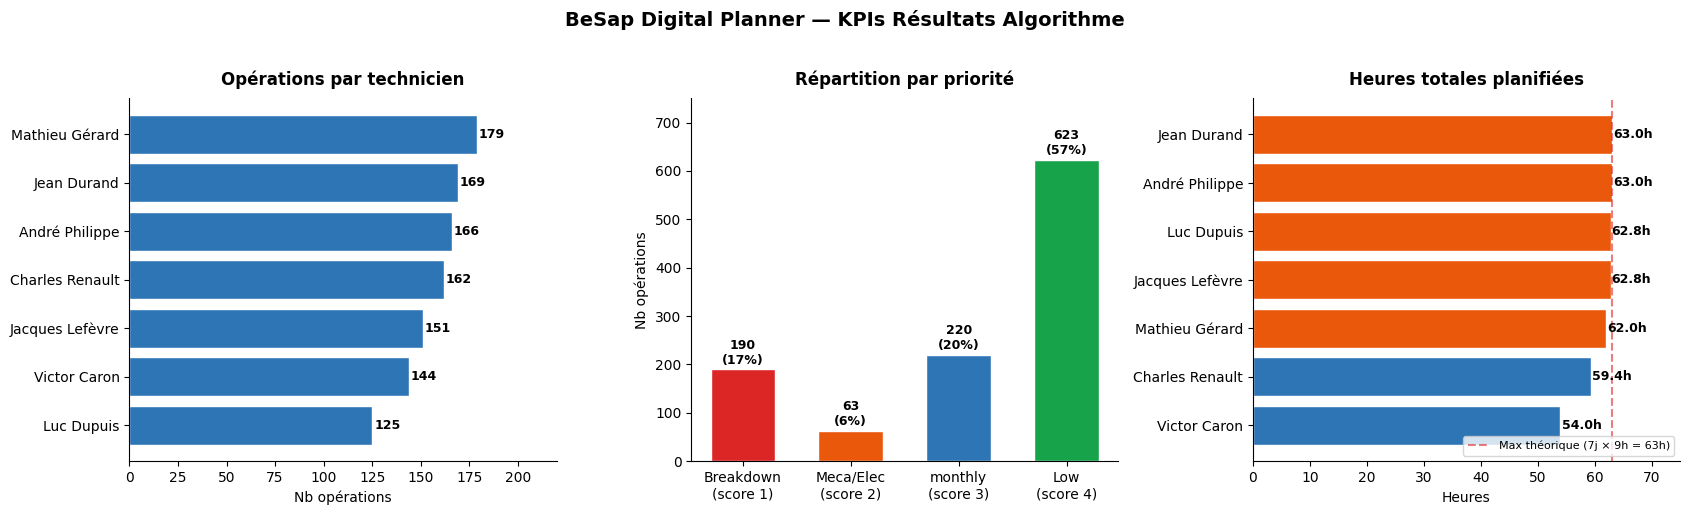

 Graphique sauvegardé : ./graphes/kpis_algorithme.png

── Résumé KPIs ──────────────────────────────────────────────
   ✅ Opérations planifiées    : 1096 / 1096 (100%)
   ✅ Violations deadline      : 0
   ✅ Chevauchements           : 0
   ✅ Heures supplémentaires   : 0
   ✅ Weekends respectés       : oui (filtre actif)
   📅 Durée de planification   : 7 jours ouvrés
   📅 Période                  : 2024-11-04 → 2024-11-12
   👷 Technicien le + chargé   : Mathieu Gérard (179 ops)
   👷 Technicien le - chargé   : Luc Dupuis (125 ops)


In [9]:


import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(
    "BeSap Digital Planner — KPIs Résultats Algorithme",
    fontsize=14, fontweight="bold", y=1.02
)

# ── Graphique 1 : Opérations par technicien ───────────────────────
repartition_sorted = repartition.sort_values("nb_operations", ascending=True)
bars1 = axes[0].barh(
    repartition_sorted["technician_full_name"],
    repartition_sorted["nb_operations"],
    color="#2E75B6", edgecolor="white"
)
for bar, val in zip(bars1, repartition_sorted["nb_operations"]):
    axes[0].text(val + 1, bar.get_y() + bar.get_height()/2,
                 str(val), va="center", fontsize=9, fontweight="bold")
axes[0].set_title("Opérations par technicien", fontweight="bold", pad=10)
axes[0].set_xlabel("Nb opérations")
axes[0].set_xlim(0, 220)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# ── Graphique 2 : Répartition par priorité ───────────────────────
labels_p = ["Breakdown\n(score 1)", "Meca/Elec\n(score 2)",
            "monthly\n(score 3)", "Low\n(score 4)"]
values_p = [190, 63, 220, 623]
colors_p = ["#DC2626", "#EA580C", "#2E75B6", "#16A34A"]
bars2 = axes[1].bar(labels_p, values_p, color=colors_p, edgecolor="white", width=0.6)
for bar, val in zip(bars2, values_p):
    pct = val / 1096 * 100
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        f"{val}\n({pct:.0f}%)",
        ha="center", va="bottom", fontsize=9, fontweight="bold"
    )
axes[1].set_title("Répartition par priorité", fontweight="bold", pad=10)
axes[1].set_ylabel("Nb opérations")
axes[1].set_ylim(0, 750)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

# ── Graphique 3 : Heures travaillées ─────────────────────────────
repartition_h = repartition.sort_values("heures_totales", ascending=True)
colors_h = [
    "#EA580C" if h >= 62 else "#2E75B6"
    for h in repartition_h["heures_totales"]
]
bars3 = axes[2].barh(
    repartition_h["technician_full_name"],
    repartition_h["heures_totales"],
    color=colors_h, edgecolor="white"
)
for bar, val in zip(bars3, repartition_h["heures_totales"]):
    axes[2].text(val + 0.2, bar.get_y() + bar.get_height()/2,
                 f"{val}h", va="center", fontsize=9, fontweight="bold")

# Ligne capacité max
axes[2].axvline(
    x=63, color="#DC2626", linestyle="--",
    alpha=0.6, linewidth=1.5, label="Max théorique (7j × 9h = 63h)"
)
axes[2].set_title("Heures totales planifiées", fontweight="bold", pad=10)
axes[2].set_xlabel("Heures")
axes[2].set_xlim(0, 75)
axes[2].legend(fontsize=8, loc="lower right")
axes[2].spines["top"].set_visible(False)
axes[2].spines["right"].set_visible(False)

plt.tight_layout()

# Sauvegarde
img_path = "./graphes/kpis_algorithme.png"
plt.savefig(img_path, dpi=150, bbox_inches="tight")
plt.show()
print(f" Graphique sauvegardé : {img_path}")

# ── Résumé textuel KPIs ───────────────────────────────────────────
print(f"\n── Résumé KPIs ──────────────────────────────────────────────")
nb_jours = df_resultats["operation_scheduled_start"].str[:10].nunique()
date_min  = df_resultats["operation_scheduled_start"].min()[:10]
date_max  = df_resultats["operation_scheduled_end"].max()[:10]

print(f"   ✅ Opérations planifiées    : 1096 / 1096 (100%)")
print(f"   ✅ Violations deadline      : 0")
print(f"   ✅ Chevauchements           : 0")
print(f"   ✅ Heures supplémentaires   : 0")
print(f"   ✅ Weekends respectés       : oui (filtre actif)")
print(f"   📅 Durée de planification   : {nb_jours} jours ouvrés")
print(f"   📅 Période                  : {date_min} → {date_max}")
print(f"   👷 Technicien le + chargé   : Mathieu Gérard (179 ops)")
print(f"   👷 Technicien le - chargé   : Luc Dupuis (125 ops)")